In this notebook we perform different tests in order to make feature selection on the merged dataset

In [3]:
import pandas as pd
from merge_and_agregation import *
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from feature_engine.selection import (
    DropCorrelatedFeatures,
    SmartCorrelatedSelection,
    SelectByShuffling,
    SelectBySingleFeaturePerformance,
    RecursiveFeatureElimination,
)

import Config
warnings.filterwarnings("ignore")

In [4]:
#Load, agregate, clean and merge the files
df_portefeuille=pd.read_csv(f"s3://{Config.NAME}projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_reclamations= pd.read_csv(f"s3://{Config.NAME}projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_interactions=pd.read_csv(f"s3://{Config.NAME}projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_impayes= pd.read_csv(f"s3://{Config.NAME}projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")
df_consommations= pd.read_csv(f"s3://{Config.NAME}projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")

df_merged=create_clean_aggregated_dataset(df_consommations=df_consommations, df_impayes=df_impayes, df_reclamations=df_reclamations, df_portefeuille=df_portefeuille, df_interactions=df_interactions)

In [7]:
df_merged= pd.read_csv("data/data_merged.csv")

### Features selection

In [8]:
#Let's first quickly visualise the correlated features in the merged dataset
#Criterion: the pearson coefficient
correlated = DropCorrelatedFeatures(variables=None, method='pearson', threshold=0.8)
correlated.fit(df_merged)
correlated.correlated_feature_dict_

{'Unnamed: 0': {'client_code'},
 'client_code_postal': {'client_departement'},
 'client_cotisations_annualisees_n': {'client_cotisations_annualisees_n_moins1',
  'client_cotisations_annualisees_n_moins2',
  'client_cotisations_annualisees_n_plus1'},
 'client_nb_assures_contrat': {'client_nb_enfants'},
 'courtier_nb_affaires_n_moins1': {'courtier_nb_affaires_n_moins2',
  'courtier_nb_radiations_n_moins1',
  'courtier_nb_radiations_n_moins2'},
 'frais_reels': {'frais_reels_soins_medicaux',
  'reste_a_charge',
  'reste_a_charge_soins_medicaux'},
 'frais_reels_dentaire': {'nb_protheses_dentaires',
  'remb_alptis_dentaire',
  'remb_ro_dentaire'},
 'frais_reels_divers': {'remb_alptis_divers', 'remb_ro_divers'},
 'frais_reels_hospitalisation': {'remb_alptis_hospitalisation',
  'remb_ro',
  'remb_ro_hospitalisation'},
 'frais_reels_optique': {'nb_decomptes_optique',
  'remb_alptis_optique',
  'reste_a_charge_optique'},
 'frais_reels_pharmacie': {'remb_alptis_pharmacie', 'remb_ro_pharmacie'},
 

This analysis validates some of our previous hypothesis, including that the number of members in the contract directly depends on the familial situation. 


In [9]:
#Let's select the best features in each group of correlated features using RandomForest
#To identify the group of correlated features we use the Pearson coefficient again

X_train= df_merged.drop(columns="target_resiliation_6mois")
y_train= df_merged["target_resiliation_6mois"]

smart_corr = SmartCorrelatedSelection( 
    method="pearson", 
    threshold=0.7, 
    missing_values="ignore",
    selection_method="model_performance", 
    estimator=RandomForestClassifier(n_estimators=10, random_state=1), # the model from which to derive the importance
)

smart_corr.fit(X_train, y_train)

,variables,None
,method,'pearson'
,threshold,0.7
,missing_values,'ignore'
,selection_method,'model_performance'
,estimator,RandomForestC...andom_state=1)
,scoring,'roc_auc'
,cv,3
,groups,None
,confirm_variables,False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10


In [10]:
#We can see which columns this methods suggest to drop
print(f"Columns to drop : {len(smart_corr.features_to_drop_)}")
smart_corr.features_to_drop_

Columns to drop : 39


['client_anciennete_contrat_annees',
 'client_code',
 'client_code_postal',
 'client_cotisations_annualisees_n',
 'client_cotisations_annualisees_n_moins1',
 'client_cotisations_annualisees_n_moins2',
 'client_nb_enfants',
 'courtier_anciennete_annees',
 'courtier_code_apporteur',
 'courtier_nb_affaires_n_moins2',
 'courtier_nb_radiations_n_moins1',
 'courtier_nb_radiations_n_moins2',
 'frais_reels',
 'frais_reels_soins_medicaux',
 'reste_a_charge',
 'frais_reels_dentaire',
 'remb_alptis_dentaire',
 'remb_ro_dentaire',
 'reste_a_charge_dentaire',
 'frais_reels_divers',
 'remb_ro_divers',
 'frais_reels_hospitalisation',
 'remb_ro',
 'remb_ro_hospitalisation',
 'frais_reels_optique',
 'remb_alptis_optique',
 'reste_a_charge_optique',
 'remb_alptis_pharmacie',
 'remb_ro_pharmacie',
 'impaye_action_annonce_contentieux',
 'impaye_action_mise_en_demeure',
 'interaction_canal_telephone_nb',
 'interaction_nb_transferts_externalises',
 'interaction_motif_frais_courants',
 'nb_decomptes',
 'nb_d

### Features importance

In [11]:
columns_to_keep = list(set(df_merged.columns)- set(smart_corr.features_to_drop_ + ["target_resiliation_6mois"])) 

#Let's train a RandomForest on the reduced dataset
X = df_merged[columns_to_keep].select_dtypes(exclude="object")
y = df_merged["target_resiliation_6mois"]
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, train_size=0.3)
rf=RandomForestClassifier(n_estimators=100, oob_score=True)
rf.fit(X_train, y_train)
y_pred= rf.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94     92611
           1       0.01      0.47      0.02       193

    accuracy                           0.89     92804
   macro avg       0.50      0.68      0.48     92804
weighted avg       1.00      0.89      0.94     92804



<Axes: ylabel='Feature'>

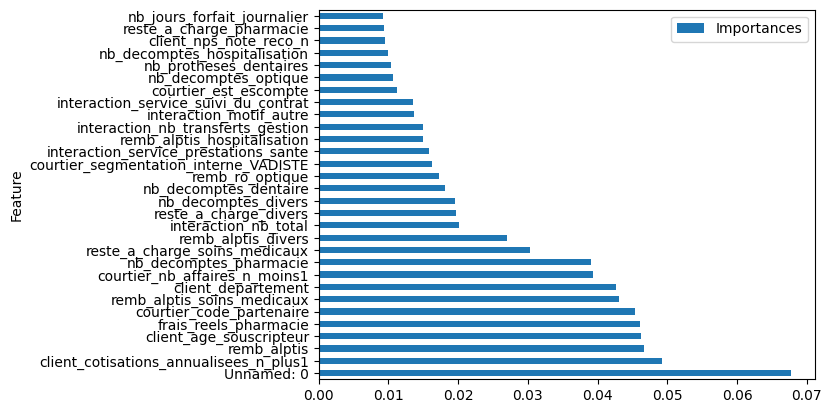

In [12]:
#Let's visualise the feature importance based on this RandomForest
importances= rf.feature_importances_
features_name = X.columns
feature_importance_df= pd.DataFrame({"Feature":features_name, "Importances": importances}).sort_values(by="Importances", ascending=False)

#Visualiation top 30 features
feature_importance_df[:30].plot(kind="barh", x= "Feature", y="Importances")

As we expected, most of the important features are linked to the annual health consumption of the clients. 
The top three most important features concern:
- the annual premium
- the annual refund made by alptis (alptis_remb)
- the age of the client
This perfectly makes sens with the litterature and the typical explicative features in churn prediction model.

We also find important features about: 
- the localisation of the client (client_departement)
- the interraction with Alptis (nb_interaction) 
- broker (courtier_code_partenaire and courtier_est_escompte)

Let's deep more into the interaction between these important features and the target with a Shap Values test.

In [17]:
X_test.shape

(92804, 136)

### Variable Selection via Penalized Logistic Regression

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

lasso_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # robuste
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        Cs=20,
        cv=5,
        scoring="f1",
        max_iter=5000,
        n_jobs=-1
    ))
])

lasso_pipe.fit(X_train, y_train)


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [ ]:
coef_lasso = pd.Series(
    lasso_pipe.named_steps["model"].coef_[0],
    index=X_train.columns
)

selected_lasso = coef_lasso[coef_lasso != 0].sort_values()
selected_lasso.head

courtier_segmentation_interne_Filiale      -0.509517
courtier_segmentation_interne_Alptis       -0.407633
client_anciennete_contrat_annees           -0.236039
interaction_autres_services                -0.125994
client_departement                         -0.113984
                                              ...   
interaction_service_suivi_du_contrat        0.150490
courtier_est_escompte                       0.190622
courtier_reseau_courtage_AFFAIRE DIRECTE    0.244492
courtier_segmentation_interne_VADISTE       0.286023
nb_decomptes_pharmacie                      0.294586
Length: 109, dtype: float64

In [27]:
ridge_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        Cs=20,
        cv=5,
        scoring="f1",
        max_iter=5000,
        n_jobs=-1
    ))
])

ridge_pipe.fit(X_train, y_train)


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [28]:
coef_ridge = pd.Series(
    ridge_pipe.named_steps["model"].coef_[0],
    index=X_train.columns
)

selected_ridge = coef_ridge[coef_ridge != 0].sort_values()
selected_ridge

courtier_segmentation_interne_Filiale   -0.273482
courtier_segmentation_interne_Alptis    -0.197120
client_anciennete_contrat_annees        -0.167294
client_departement                      -0.092206
courtier_type_commission_lineaire       -0.083115
                                           ...   
interaction_service_suivi_du_contrat     0.082089
courtier_code_partenaire                 0.097050
courtier_est_escompte                    0.112667
nb_decomptes_pharmacie                   0.220055
courtier_segmentation_interne_VADISTE    0.251033
Length: 130, dtype: float64

In [ ]:
enet_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        class_weight="balanced",
        l1_ratios=[0.2, 0.5, 0.8],
        Cs=20,
        cv=5,
        scoring="f1",
        max_iter=7000,
        n_jobs=-1
    ))
])

enet_pipe.fit(X_train, y_train)


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_s

In [ ]:
coef_enet = pd.Series(
    enet_pipe.named_steps["model"].coef_[0],
    index=X_train.columns
)

selected_enet = coef_enet[coef_enet != 0].sort_values()
selected_enet

### Sentiment analysis on interaction texte mails

In [ ]:
#Mail cleaning
mails= df_interactions["interaction_texte_mail"].str.split("xcont").str[1].dropna()

#Mails sous motif Résiliation
mails_resiliation= df_interactions[df_interactions["interaction_motif"].isin(["Résiliation"])]["interaction_texte_mail"].str.split("xcont").str[1].dropna()
#bcp de spam Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent i



In [ ]:
from transformers import pipeline
pipe_sentiment_analysis = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

#Test sur quelques corps d'df_interactions
for mail in mails[3:13]:
    print(f"Mail:\n{Mail}\nSentiment: {pipe_sentiment_analysis(mails)}\n")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 20.6 MB/s  0:00:30m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 8.5 MB/s  0:00:01eta 0:00:01m
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/594.3 MB 83.8 MB/s eta 0:00:07

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
ERROR: Operation cancelled by user
^C


NameError: name 'torch' is not defined

### Pattern among the brokers: PCA and Clustering

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


#Let's focus on the variables linked to the broker
broker_columns=[c for c in df_merged.columns if c.startswith("courtier")]
X_broker=df_merged[broker_columns]
X_broker=pd.get_dummies(data=X_broker, columns= ["courtier_reseau_courtage"])
print(f"Number of columns about the broker {len(X_broker.columns)}")
X_broker.columns

Number of columns about the broker 34


Index(['courtier_code_partenaire', 'courtier_anciennete_annees',
       'courtier_code_apporteur', 'courtier_est_escompte',
       'courtier_nb_affaires_n_moins1', 'courtier_nb_radiations_n_moins1',
       'courtier_nb_affaires_n_moins2', 'courtier_nb_radiations_n_moins2',
       'courtier_changement_dans_les_12_mois',
       'courtier_segmentation_interne_Alptis',
       'courtier_segmentation_interne_CMA',
       'courtier_segmentation_interne_Dilemme',
       'courtier_segmentation_interne_Filiale',
       'courtier_segmentation_interne_Groupements',
       'courtier_segmentation_interne_Inactif à relancer',
       'courtier_segmentation_interne_Miltis',
       'courtier_segmentation_interne_Non catégorisé',
       'courtier_segmentation_interne_Nouveau',
       'courtier_segmentation_interne_Opportuniste',
       'courtier_segmentation_interne_Partenariats',
       'courtier_segmentation_interne_Petit Producteur',
       'courtier_segmentation_interne_Potentiel',
       'courtier_s

In [ ]:

#Let's standardize the values (except the booleans)
X_broker_stand = StandardScaler().fit_transform(X_broker.select_dtypes(exclude= ["bool"]))

pca=PCA(n_components=4)
pca_broker=pca.fit_transform(X_broker_stand)
pca_broker_df = pd.DataFrame(data = pca_broker
             , columns = ['principal component 1', 'principal component 2', 'pca 3','pca 4'])
pca_broker_df

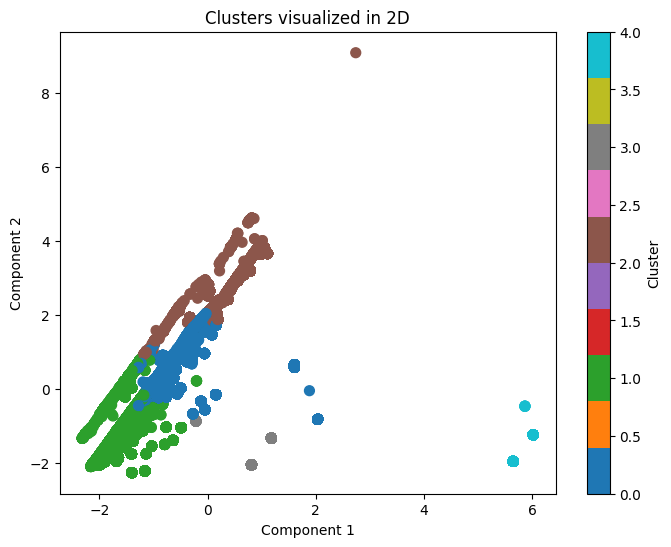

In [ ]:

pipeline = Pipeline(steps=[
    ("pca", PCA(n_components=0.9)),   # keep 90% variance
    ("kmeans", KMeans(n_clusters=5, random_state=42))
])
labels = pipeline.fit_predict(X_broker_stand)

#Visualisation
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.pyplot as plt

# If sparse → TruncatedSVD is better
svd = TruncatedSVD(n_components=2, random_state=42)
X_broker_2d = svd.fit_transform(preprocessor.fit_transform(X_broker))  # preprocessor from previous pipeline
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(preprocessor.fit_transform(X_broker))

plt.figure(figsize=(8,6))
plt.scatter(X_broker_2d[:,0], X_broker_2d[:,1], c=labels, cmap="tab10", s=50)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Clusters visualized in 2D")
plt.colorbar(label="Cluster")
plt.show()
